# Lab4
## Anzhelika Mazurenko CS32

### The task contains 2 parts:
1. Play with [Tensorflow Playground](https://playground.tensorflow.org) and save a bunch of screenshots (at least 10).
2. Solve the classification problem on your dataset from the Lab : play with number of neurons, function activation and learning rate (and if you wish play with learning rate schedule)

![](images/img1.jpg)
![](images/img2.jpg)
![](images/img3.jpg)
![](images/img4.jpg)
![](images/img5.jpg)
![](images/img6.jpg)
![](images/img7.jpg)
![](images/img8.jpg)
![](images/img9.jpg)
![](images/img10.jpg)
![](images/img11.jpg)
![](images/img12.jpg)
![](images/img13.jpg)

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

In [91]:
df = pd.read_csv('gender_classification.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [92]:
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])  # Female=0, Male=1
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0


In [93]:
X = df.drop('gender', axis=1).values #ознаки
y = df['gender'].values #цільова змінна

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=97)

In [94]:
# Функція створення моделі з параметрами
# створює нейронну мережу для бінарної класифікації
def create_model(neurons=16, activation='relu', learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(neurons, activation=activation))
    model.add(Dense(neurons, activation=activation))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [95]:
# Конфігурації для перевірки
configs = [
    {'neurons': 64, 'activation': 'sigmoid', 'lr': 0.001},
    {'neurons': 32, 'activation': 'sigmoid', 'lr': 0.003},
    {'neurons': 4, 'activation': 'tanh', 'lr': 0.01},
    {'neurons': 64, 'activation': 'tanh', 'lr': 0.001},
    {'neurons': 2, 'activation': 'sigmoid', 'lr': 0.2},
]

results = []
history_dicts = []

In [96]:
# Навчання та оцінка моделей
for config in configs:
    #Створення та навчання моделі
    model = create_model(neurons=config['neurons'], activation=config['activation'], learning_rate=config['lr'])
    history = model.fit(X_train, y_train, epochs=55, batch_size=16, verbose=0, validation_split=0.2)

#Оцінка моделі
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = (model.predict(X_test) > 0.5).astype(int)  #Прогнози моделі: якщо ймовірність > 0.5 —
                                                        # класифікуємо як 1 (тобто “Male”).
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Neurons': config['neurons'],
        'Activation': config['activation'],
        'Learning Rate': config['lr'],
        'Test Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1 Score': report['1']['f1-score']
    })
    history_dicts.append((config, history))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


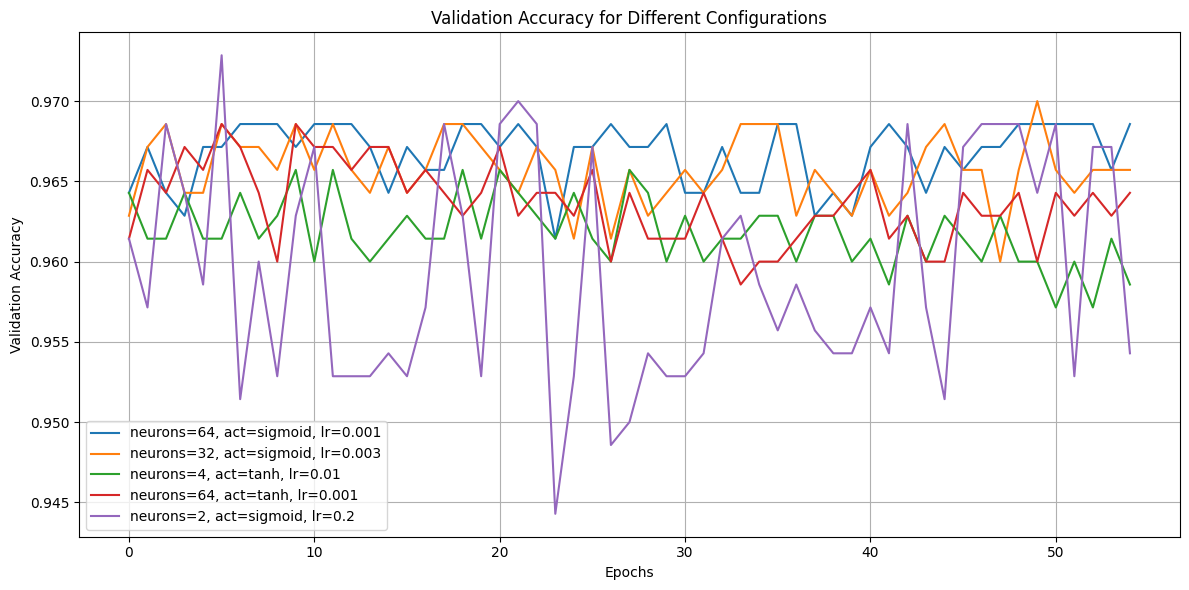

In [97]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
for config, history in history_dicts:
    label = f"neurons={config['neurons']}, act={config['activation']}, lr={config['lr']}"
    plt.plot(history.history['val_accuracy'], label=label)

plt.title("Validation Accuracy for Different Configurations")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [98]:
# Конфігурації для перевірки
configs = [
    {'neurons': 128, 'activation': 'relu', 'lr': 0.0005},
    {'neurons': 8, 'activation': 'sigmoid', 'lr': 0.02},
    {'neurons': 24, 'activation': 'relu', 'lr': 0.002},
    {'neurons': 32, 'activation': 'tanh', 'lr': 0.005},
    {'neurons': 8, 'activation': 'relu', 'lr': 0.01},
]

history_dicts = []

In [99]:
# Навчання та оцінка моделей
for config in configs:
    model = create_model(neurons=config['neurons'], activation=config['activation'], learning_rate=config['lr'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0, validation_split=0.2)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Neurons': config['neurons'],
        'Activation': config['activation'],
        'Learning Rate': config['lr'],
        'Test Accuracy': acc,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1 Score': report['1']['f1-score']
    })
    history_dicts.append((config, history))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


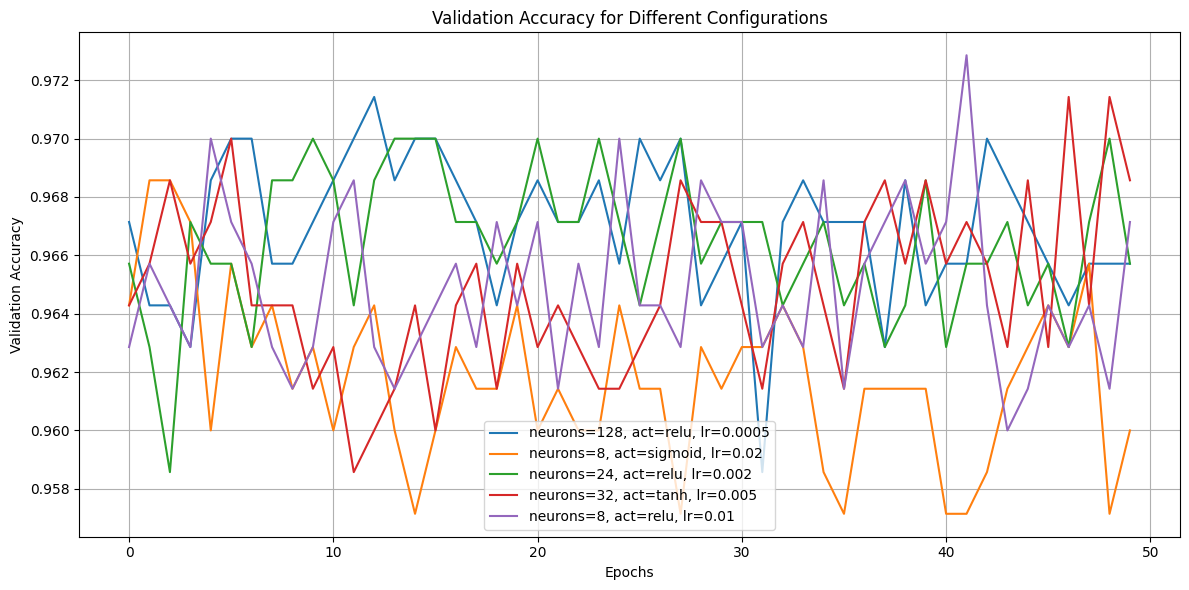

In [100]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
for config, history in history_dicts:
    label = f"neurons={config['neurons']}, act={config['activation']}, lr={config['lr']}"
    plt.plot(history.history['val_accuracy'], label=label)

plt.title("Validation Accuracy for Different Configurations")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [102]:
# Вивід таблиці з результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
results_df

,Neurons,Activation,Learning Rate,Test Accuracy,Precision,Recall,F1 Score
0,128,relu,0.0005,0.978681,0.987569,0.968835,0.978112
1,32,sigmoid,0.0030,0.974017,0.982069,0.964770,0.973342
2,24,relu,0.0020,0.974017,0.983402,0.963415,0.973306
3,8,sigmoid,0.0200,0.974017,0.980743,0.966125,0.973379
4,64,sigmoid,0.0010,0.973351,0.984722,0.960705,0.972565
5,8,relu,0.0100,0.973351,0.983380,0.962060,0.972603
6,4,tanh,0.0100,0.970686,0.975342,0.964770,0.970027
7,32,tanh,0.0050,0.970686,0.972752,0.967480,0.970109
8,64,tanh,0.0010,0.969354,0.972678,0.964770,0.968707
9,2,sigmoid,0.2000,0.956029,0.992669,0.917344,0.953521


Активна функція ReLU у поєднанні з великою кількістю нейронів (128) та низькою швидкістю навчання (0.0005) дає найкращу загальну точність.

Конфігурація з neurons=24, activation=relu, lr=0.002 показала найвищий F1-скоре.


Конфігурація neurons=2, sigmoid, lr=0.2 дала найгірший результат:

Найнижча точність, F1, Precision.
Причина — занадто мало нейронів + дуже висока швидкість навчання.

Збалансована архітектура (від 24 до 128 нейронів) + ReLU забезпечує найкращі результати.

Низьке значення learning rate (0.0005–0.002) показало стабільну продуктивність.
Високі значення (0.2, 0.02) — знижують якість.

Sigmoid працює добре лише при великій кількості нейронів та помірному lr.
При neurons=2 або lr=0.2 — якість значно падає.

Tanh показала непогані результати в конфігураціях neurons=32 або 64.

F1-score > 0.97 досягається у кількох комбінаціях, що свідчить про хорошу збалансованість Precision/Recall.